SHAFE:JAWAD

Here we bring in the tools we need for this perceptron exercise. matplotlib.pyplot handles all our plotting needs so we can visualize the data and decision boundary. numpy gives us the math operations especially dot products which are CENTRAL to how perceptrons work. sklearn.datasets lets us generate fake classification data quickly so we dont have to load external files.

After imports we create a synthetic dataset with 150 points split into 2 clusters. The make_blobs function is super handy for testing classifiers because you KNOW the data should be separable. We set random_state=2 so everyone gets the same random data. Then we plot it with red triangles for class 0 and blue squares for class 1.

Text(0.5, 1.0, 'Random Classification Data with 2 classes')

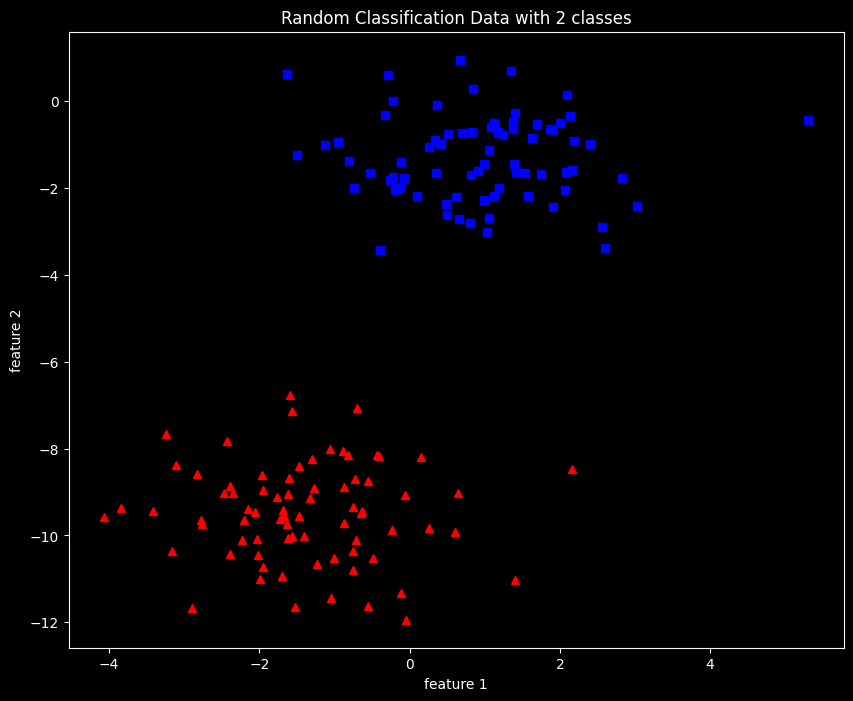

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets

X, y = datasets.make_blobs(n_samples=150,n_features=2,
                           centers=2,cluster_std=1.05,
                           random_state=2)



#Plotting
fig = plt.figure(figsize=(10,8))
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'r^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title('Random Classification Data with 2 classes')

SHAFE:JAWAD

The decision function is the CORE of a perceptron. It takes an input x, multiplies it by weights w, adds bias b, then checks if the result is positive. If positive the perceptron fires and outputs 1, otherwise 0. This is basically asking which side of a line does this point fall on. The dot product combines all features into one number that tells us the answer.

In [2]:
def decision(x, w, b):
    return np.dot(x,w) + b > 0

SHAFE:JAWAD

This is the main training function for our perceptron. We start with all weights at zero and bias at zero. Then for each epoch we go through EVERY training example. If the perceptron already predicts correctly we skip that example and move on. But if it gets it WRONG we need to update the weights and bias.

The update rule is simple. If we predicted 0 but should have predicted 1 then y[idx] minus d equals 1 so we ADD to the weights. If we predicted 1 but should have predicted 0 then y[idx] minus d equals negative 1 so we SUBTRACT from weights. The learning rate controls how big each step is. Bias gets updated similarly just without the x_i multiplier.

In [3]:
def perceptron(X, y, lr, epochs):  # SHAFE:JAWAD lr and epochs are tunable
    m, n = X.shape
    
    w = np.zeros(n)
    b = 0
    
    # Training.
    for epoch in range(epochs):
        for idx, x_i in enumerate(X):
            d = decision(x_i, w, b)
            
            if d == y[idx]:
                continue
            
            w = w + lr * (y[idx] - d) * x_i
            b = b + lr * (y[idx] - d)
    
    return w, b

SHAFE:JAWAD

This helper function draws the decision boundary that our perceptron learned. The boundary is just a straight line that separates the two classes. To find the line equation from our weights, we use some algebra to convert from the form w dot x plus b equals 0 into y equals mx plus c format. The slope m comes from negative w0 divided by w1 and the intercept c comes from negative b divided by w1. Then we draw this line in yellow over our scattered data points.

In [4]:
def plot_decision_boundary(X, theta, b):
    """Plots the decision boundary"""
    x1 = [min(X[:,0]), max(X[:,0])]
    m = -theta[0] / theta[1]
    c = -b / theta[1]
    x2 = x1 * np.asarray([m], dtype=np.float64) + c

    # Plotting
    fig = plt.figure(figsize=(10,8))
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "r^")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
    plt.xlabel("feature 1")
    plt.ylabel("feature 2")
    plt.title('Perceptron Algorithm')
    plt.plot(x1, x2, 'y-')

SHAFE:JAWAD

Now we actually run the training. We use a learning rate of 0.5 which is pretty aggressive but works fine for this simple data. 100 epochs gives the perceptron plenty of chances to see each example and adjust. After training we get back the learned weights w and bias b, then we visualize the result. If everything worked right the yellow line should cleanly separate the red triangles from blue squares.

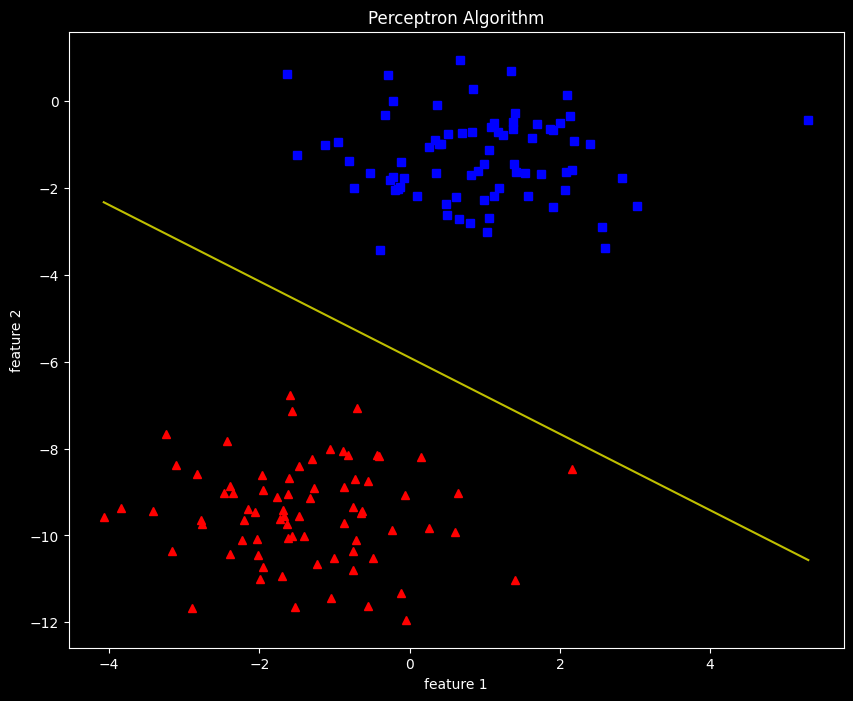

In [5]:
w, b = perceptron(X, y, 0.5, 100)  # SHAFE:JAWAD lr=0.5, epochs=100 - can try lr=0.1 or 1.0
plot_decision_boundary(X, w, b)

SHAFE:JAWAD
WHAT WE HAVE LEARNED

1. The PERCEPTRON is the simplest neural network with just one neuron. It takes inputs, multiplies by weights, adds a bias, and applies a step function to output 0 or 1.

2. The perceptron learning rule is simple: if the prediction is wrong, adjust the weights in the direction that would fix it. If correct, do nothing.

3. The STEP FUNCTION outputs 1 if the weighted sum is positive and 0 otherwise. This creates a hard decision boundary with no probability like logistic regression.

4. Perceptrons can only learn LINEARLY SEPARABLE patterns. If you cannot draw a straight line between the classes, the perceptron will never converge.

5. The DOT PRODUCT between input vector and weight vector determines which side of the decision boundary a point falls on.

6. Training iterates through examples and updates weights only when mistakes are made. For linearly separable data it is GUARANTEED to converge.

7. The perceptron is historically important as the foundation for neural networks but limited in practice because most real problems are not linearly separable.